In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


## Setup

In [ ]:
import os
import numpy as np
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D, fit_3D_gan
from utils.loss_functions import recon_loss, ssim_L1_2d_loss
from models.alzheiminator_3d import ResidualUNet3D, Discriminator3D, Generator3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Flush cuda memory

In [3]:
torch.cuda.empty_cache()

Common Variables

In [4]:
model_epochs = 2001
print_every = 200
save_every = 500

In [5]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


## 3D U-Net

In [6]:
output_dir = "out/unet_models"
model_path = f"{output_dir}/3d_unet_model.pt"
model = ResidualUNet3D(in_ch=1, base=32).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [7]:
# Load existing model if it exists
if os.path.isfile(model_path):
    print("Loading existing model")
    model.load_state_dict(torch.load(model_path))
else:
    print("No existing model found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing model found, starting fresh training.
562 training pairs


In [8]:
model, snapshots = fit_3D(
    model=model,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    criterion=recon_loss,
    epochs=model_epochs,
    print_every=print_every,
    save_every=save_every
)

[Iter 0] total: 0.657306 (custom criterion) + TV
Saved snapshot at iter 0 (mid-axial slice)
[Iter 200] total: 0.171457 (custom criterion) + TV
[Iter 400] total: 0.160495 (custom criterion) + TV
Saved snapshot at iter 500 (mid-axial slice)
[Iter 600] total: 0.136462 (custom criterion) + TV
[Iter 800] total: 0.064246 (custom criterion) + TV
[Iter 1000] total: 0.062235 (custom criterion) + TV
Saved snapshot at iter 1000 (mid-axial slice)
[Iter 1200] total: 0.062095 (custom criterion) + TV
[Iter 1400] total: 0.059719 (custom criterion) + TV
Saved snapshot at iter 1500 (mid-axial slice)
[Iter 1600] total: 0.061951 (custom criterion) + TV
[Iter 1800] total: 0.067970 (custom criterion) + TV
[Iter 2000] total: 0.064576 (custom criterion) + TV
Saved snapshot at iter 2000 (mid-axial slice)


Displaying snapshot from pair 0, loss: 0.6573


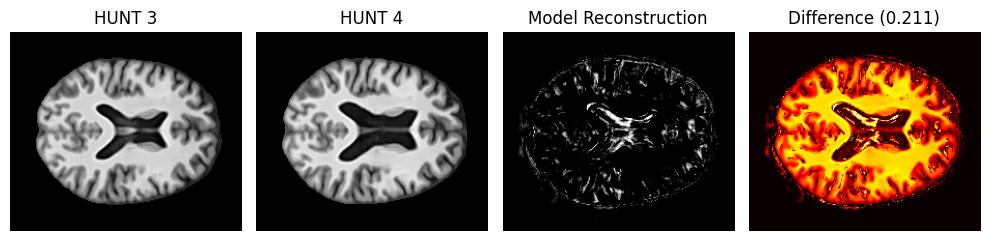

Displaying snapshot from pair 500, loss: 0.1512


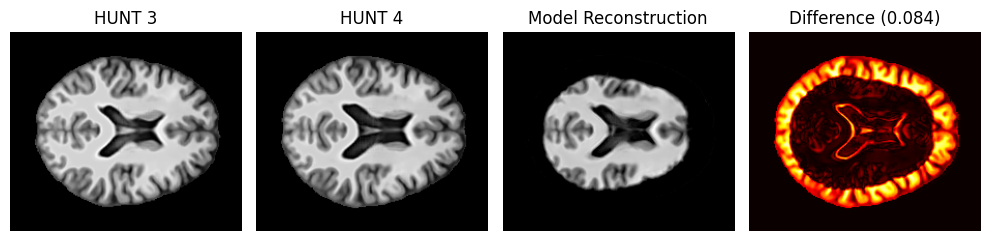

Displaying snapshot from pair 1000, loss: 0.0622


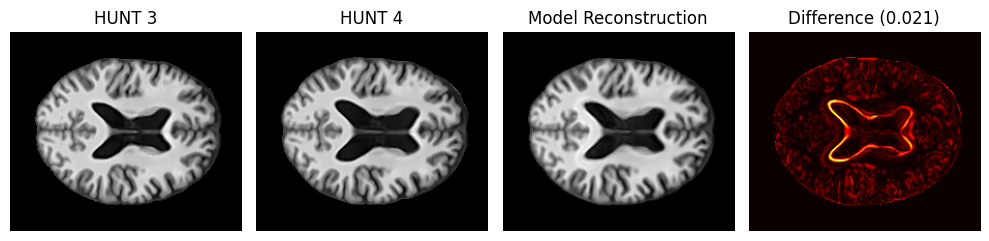

Displaying snapshot from pair 1500, loss: 0.0639


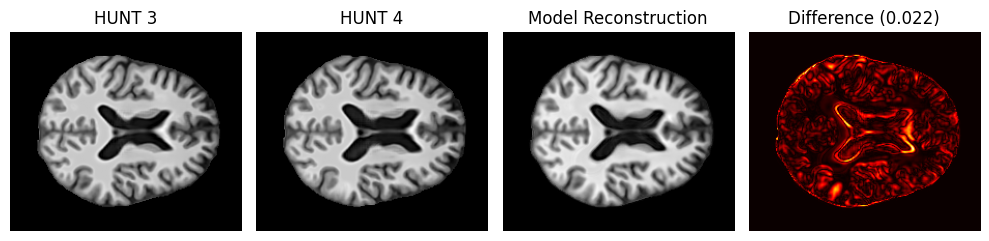

Displaying snapshot from pair 2000, loss: 0.0646


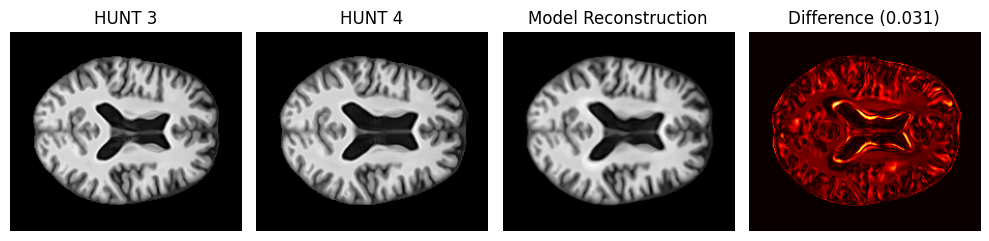

In [9]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [10]:
# Save the final model to /out directory
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/unet_models/3d_unet_model.pt


## MP-GAN

In [11]:
output_dir = "out/gan_models"
generator_path = f"{output_dir}/3d_mpgan_model_G.pt"
discriminator_path = f"{output_dir}/3d_mpgan_model_D.pt"

G = Generator3D(in_channels=1, out_channels=1).to(device)
D = Discriminator3D(in_channels=1).to(device)

In [12]:
# Load existing model if it exists
if os.path.isfile(generator_path) and os.path.isfile(discriminator_path):
    print("Loading existing GAN models")
    G.load_state_dict(torch.load(generator_path)) 
    D.load_state_dict(torch.load(discriminator_path))
else:
    print("No existing GAN models found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing GAN models found, starting fresh training.
562 training pairs


In [13]:
# Use with fit_3D
G, D, snapshots = fit_3D_gan(
    G=G,
    D=D,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    lambda_recon=1.0,
    lambda_adv=0.005,
    epochs=model_epochs,
    save_every=save_every,
    print_every=print_every
)

[Iter 0] D_total=0.6914 G_total=0.7231 Recon=0.7189 AdvG=0.8486
Saved snapshot at iter 0
[Iter 200] D_total=0.2022 G_total=0.5235 Recon=0.5144 AdvG=1.8351
[Iter 400] D_total=0.0831 G_total=0.5034 Recon=0.4898 AdvG=2.7212
Saved snapshot at iter 500
[Iter 600] D_total=0.0521 G_total=0.5042 Recon=0.4886 AdvG=3.1158
[Iter 800] D_total=0.0385 G_total=0.4879 Recon=0.4709 AdvG=3.4037
[Iter 1000] D_total=0.0298 G_total=0.4705 Recon=0.4521 AdvG=3.6654
Saved snapshot at iter 1000
[Iter 1200] D_total=0.0203 G_total=0.4710 Recon=0.4500 AdvG=4.1948
[Iter 1400] D_total=0.0205 G_total=0.4522 Recon=0.4322 AdvG=3.9895
Saved snapshot at iter 1500
[Iter 1600] D_total=0.0248 G_total=0.4099 Recon=0.3919 AdvG=3.6005
[Iter 1800] D_total=0.0131 G_total=0.3811 Recon=0.3582 AdvG=4.5910
[Iter 2000] D_total=0.0112 G_total=0.3558 Recon=0.3326 AdvG=4.6340
Saved snapshot at iter 2000


Displaying snapshot from pair 0


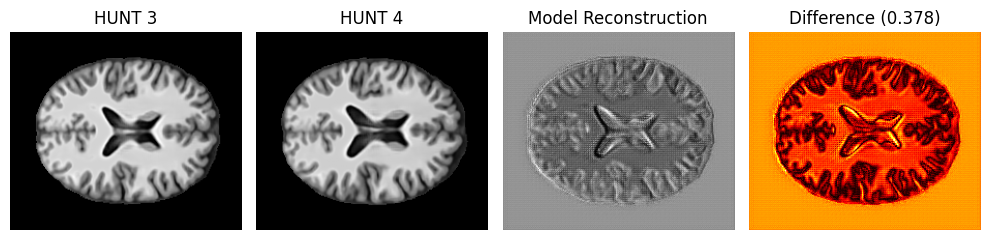

Displaying snapshot from pair 500


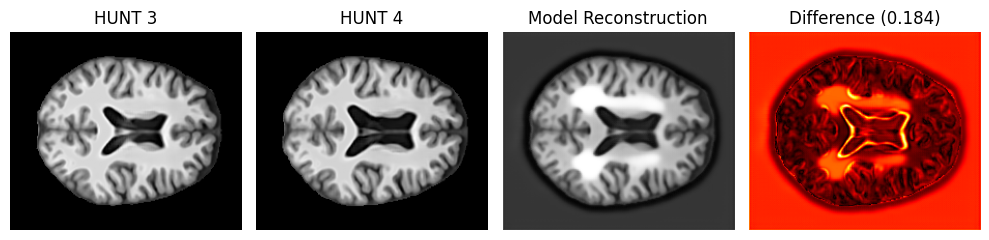

Displaying snapshot from pair 1000


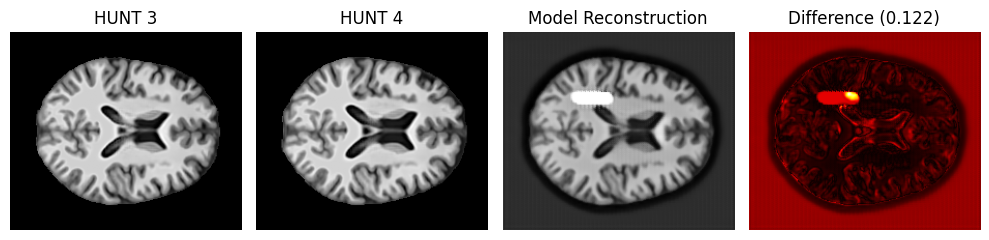

Displaying snapshot from pair 1500


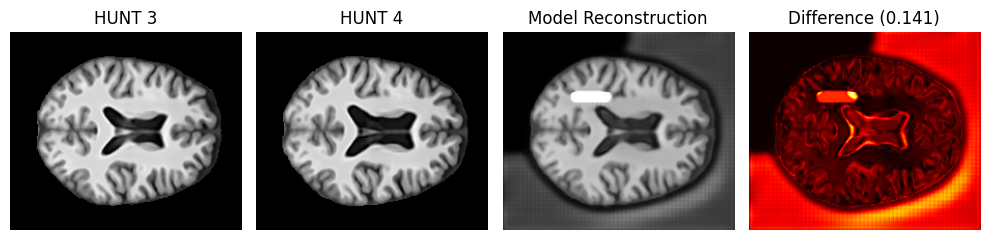

Displaying snapshot from pair 2000


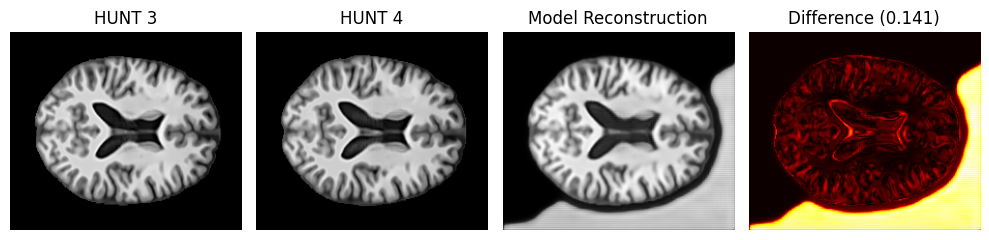

In [15]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

## Display evenly spaced results from both models

In [16]:
test_images = 4

# Same split as during training
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


In [ ]:
for i in range(test_images):
    padding = 15
    slice = int(padding + i * ((192 - 2 * padding) / test_images))
    candidate = random.randint(0, len(test_pairs)-1)

    # Generate 3D predictions
    x_num, y_num = data_loader.load_from_path(path=test_pairs[candidate][0], crop_size=(64, 192, 224)), data_loader.load_from_path(path=test_pairs[candidate][1], crop_size=(64, 192, 224))
    x = data_loader.to_torch_img(x_num, device)
    y = data_loader.to_torch_img(y_num, device)
    unet_recon_tensor = model(x)
    mpgan_recon_tensor = G(x)

    # Convert Tensor reconstructions to numpy for display
    recon_unet = data_loader.to_numpy_img(unet_recon_tensor)[slice]
    recon_mpgan = data_loader.to_numpy_img(mpgan_recon_tensor)[slice]

    # How much the models change from the input
    change_unet = np.abs(recon_unet - x_num[slice])
    change_mpgan = np.abs(recon_mpgan - x_num[slice])

    # Difference between reconstructions and ground truth
    diff_unet = np.abs(recon_unet - y_num[slice])
    diff_mpgan = np.abs(recon_mpgan - y_num[slice])
    hunt_diff = np.abs(x_num[slice] - y_num[slice])

    # Prediction errors
    pred_error_unet = ssim_L1_2d_loss(unet_recon_tensor, y).item()
    pred_error_mpgan = ssim_L1_2d_loss(mpgan_recon_tensor, y).item()
    print(f"Displaying results for test image {candidate}, slice {slice}")

    # Hunt 3, Hunt 4, and the difference between them
    data_loader.display_slices(
        slices=[x_num[slice], y_num[slice], hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The two models’ outputs
    data_loader.display_slices(
        slices=[recon_unet, recon_mpgan],
        slice_labels=["Unet Recon", "MPGAN Recon"],
        slice_colors=["gray", "gray"]
    )

    # The two models’ change from HUNT 3
    data_loader.display_slices(
        slices=[change_unet, change_mpgan],
        slice_labels=["Unet Change", "MPGAN Change"],
        slice_colors=["hot", "hot"]
    )

    # The two models’ difference from HUNT 4
    data_loader.display_slices(
        slices=[diff_unet, diff_mpgan],
        slice_labels=[
            f"Slice Loss ({pred_error_unet:.3f})",
            f"Slice loss ({pred_error_mpgan:.3f})",
        ],
        slice_colors=["hot", "hot"]
    )

NotImplementedError: Got 4D input, but trilinear mode needs 5D input